In [13]:
!pip install mealpy
!pip install pygad
!pip install deap

In [19]:
import numpy as np
import matplotlib.pyplot as plt

NUM_PUNTOS = 20          # Puntos intermedios entre inicio y fin
TIPO = 'espiral'        # 'escalon', 'lissajous', 'espiral'
ALTURA_NEUTRA = -0.30   # Valor base en Z
a1 = 1.0                # Parámetro lateral para el eje Y

# Vector de tiempo para 200 puntos
t = np.linspace(0, 4.0, 200)

def obtener_punto_vectorial(t_vals, tipo, lado):
    px_l, py_l, pz_l = [], [], []
    for t_val in t_vals:
        t_mod = t_val % 4.0
        if tipo == 'escalon':
            py = lado * a1 + 0.05
            tercio = 4.0 / 3.0
            if t_mod < tercio:
                px = -0.1
                pz = ALTURA_NEUTRA
            elif t_mod < 2 * tercio:
                px = 0.0
                pz = ALTURA_NEUTRA + 0.1
            else:
                px = 0.1
                pz = ALTURA_NEUTRA + 0.1
        elif tipo == 'lissajous':
            px = 0.08 * np.sin(2 * np.pi * t_val)
            py = lado * a1 + 0.08 * np.sin(3 * np.pi * t_val)
            pz = ALTURA_NEUTRA + 0.04 * np.sin(5 * np.pi * t_val)
        else:  # espiral
            vueltas = 4
            altura = 0.10
            s = t_mod / 4.0
            theta = 2 * np.pi * vueltas * s
            radio = 0.03 + 0.05 * s
            px = radio * np.cos(theta)
            py = lado * a1 + radio * np.sin(theta)
            pz = ALTURA_NEUTRA - altura * s

        px_l.append(px)
        py_l.append(py)
        pz_l.append(pz)
    return np.column_stack((px_l, py_l, pz_l))

# Generar la trayectoria basada en la función
trayectoria = obtener_punto_vectorial(t, TIPO, lado=1.0)

def distancia_punto_segmento(P, A, B):
    AB = B - A
    AP = P - A
    den = np.dot(AB, AB)
    if den < 1e-12:
        return np.linalg.norm(P - A)
    u = np.clip(np.dot(AP, AB) / den, 0, 1)
    Q = A + u * AB
    return np.linalg.norm(P - Q)

def calcular_rmse(vertices, trayectoria):
    errores = []
    for P in trayectoria:
        mejor = np.inf
        for i in range(len(vertices) - 1):
            d = distancia_punto_segmento(P, vertices[i], vertices[i + 1])
            if d < mejor:
                mejor = d
        errores.append(mejor)
    return np.sqrt(np.mean(np.square(errores)))

def individuo_a_vertices(ind):
    ind_int = np.array(ind).astype(int)
    idx_ordenados = np.sort(np.unique(np.clip(ind_int, 1, len(trayectoria) - 2)))

    if len(idx_ordenados) < NUM_PUNTOS:
        faltantes = np.setdiff1d(np.arange(1, len(trayectoria) - 1), idx_ordenados)
        idx_ordenados = np.sort(np.append(idx_ordenados, np.random.choice(faltantes, NUM_PUNTOS - len(idx_ordenados), replace=False)))
    elif len(idx_ordenados) > NUM_PUNTOS:
        idx_ordenados = idx_ordenados[:NUM_PUNTOS]

    return np.vstack((
        trayectoria[0],
        trayectoria[idx_ordenados],
        trayectoria[-1]
    ))

def fitness_func(ind):
    v = individuo_a_vertices(ind)
    return calcular_rmse(v, trayectoria)

In [20]:
from mealpy import IntegerVar, GA

def objective_function(solution):
    return fitness_func(solution)

# Definir los límites del problema (índices enteros entre 1 y len(trayectoria)-2)
problem_dict = {
    "bounds": IntegerVar(lb=[1] * NUM_PUNTOS, ub=[len(trayectoria) - 2] * NUM_PUNTOS, name="indices"),
    "obj_func": objective_function,
    "minmax": "min",
}

# Configurar y ejecutar el Algoritmo Genético base de Mealpy
model = GA.BaseGA(epoch=80, pop_size=40, pc=0.8, pm=0.2)
best_agent = model.solve(problem_dict)

print(f"\nMejor RMSE (MEALPY): {best_agent.target.fitness}")
mejor_individuo = best_agent.solution

INFO:mealpy.evolutionary_based.GA.BaseGA:BaseGA(epoch=80, pop_size=40, pc=0.8, pm=0.2)
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 1, Current best: 0.013675063558946711, Global best: 0.013569294324731813, Runtime: 3.29333 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 2, Current best: 0.014177643354252504, Global best: 0.013569294324731813, Runtime: 4.49423 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 3, Current best: 0.013840048316556863, Global best: 0.013569294324731813, Runtime: 3.53075 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 4, Current best: 0.014227871468918123, Global best: 0.013569294324731813, Runtime: 3.20117 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 5, Current best: 0.013670201589360971, Global best: 0.013569294324731813, Runtime: 3.20214 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 6, Current best: 0.013603655045909739, G


Mejor RMSE (MEALPY): 0.011270679412294583


In [21]:
import pygad

def fitness_pygad(ga_instance, solution, solution_idx):
    rmse = fitness_func(solution.astype(int))
    return 1.0 / (1.0 + rmse)

ga_instance = pygad.GA(
    num_generations=80,
    sol_per_pop=40,
    num_parents_mating=20,  # <-- Parámetro obligatorio faltante añadido
    num_genes=NUM_PUNTOS,
    gene_type=int,
    init_range_low=1,
    init_range_high=len(trayectoria) - 2,
    fitness_func=fitness_pygad,
    mutation_percent_genes=20,
    parent_selection_type="sss",
    crossover_type="single_point",
    mutation_type="random"
)

ga_instance.run()

solution, solution_fitness, _ = ga_instance.best_solution()
print(f"\nMejor RMSE (PyGAD): {(1.0 / solution_fitness) - 1.0}")


Mejor RMSE (PyGAD): 0.010252932704255757


In [22]:
import random
from deap import base, creator, tools, algorithms

# Minimizar la función objetivo (RMSE)
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("attr_idx", random.randint, 1, len(trayectoria) - 2)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_idx, n=NUM_PUNTOS)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def eval_fitness(individual):
    return (fitness_func(np.array(individual)),)

toolbox.register("evaluate", eval_fitness)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutUniformInt, low=1, up=len(trayectoria) - 2, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

# Ejecución del Algoritmo Genético
pop = toolbox.population(n=40)
hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("min", np.min)

algorithms.eaSimple(pop, toolbox, cxpb=0.8, mutpb=0.2, ngen=80, stats=stats, halloffame=hof, verbose=True)

print(f"\nMejor RMSE (DEAP): {-hof[0].fitness.values[0]}")

gen	nevals	min      
0  	40    	0.0142111
1  	30    	0.0138135
2  	37    	0.0129868
3  	35    	0.0137267
4  	32    	0.0131547
5  	32    	0.0131418
6  	35    	0.0132519
7  	36    	0.0127908
8  	36    	0.0123299
9  	31    	0.0112275
10 	25    	0.0112275
11 	40    	0.0119985
12 	31    	0.0102489
13 	33    	0.0102489
14 	38    	0.0106402
15 	30    	0.0102489
16 	33    	0.0102489
17 	33    	0.0104364
18 	39    	0.0106402
19 	33    	0.0104364
20 	26    	0.0103042
21 	36    	0.0106402
22 	38    	0.0102421
23 	27    	0.0104692
24 	32    	0.0104692
25 	33    	0.0102421
26 	32    	0.0102421
27 	31    	0.0102421
28 	37    	0.0109177
29 	38    	0.0102421
30 	34    	0.0102421
31 	33    	0.0102421
32 	33    	0.0102421
33 	34    	0.0102421
34 	33    	0.0102567
35 	30    	0.00949498
36 	33    	0.00949498
37 	35    	0.00961676
38 	40    	0.00986948
39 	37    	0.00947567
40 	33    	0.00945871
41 	35    	0.00929986
42 	31    	0.00969875
43 	39    	0.0101963 
44 	35    	0.00945871
45 	34    	0.00945871
46

MEALPY
RMSE Obtenido: 0.012000



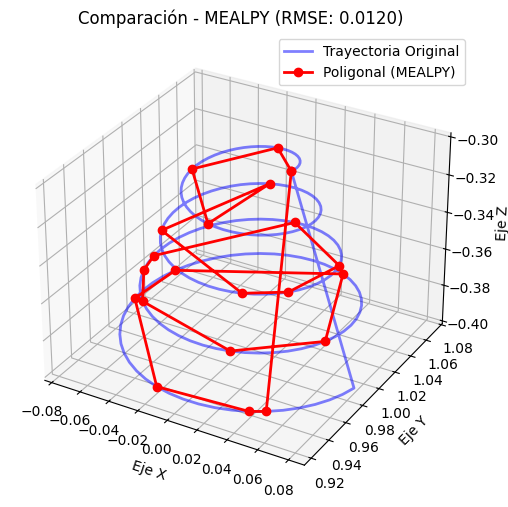

PyGAD
RMSE Obtenido: 0.010253



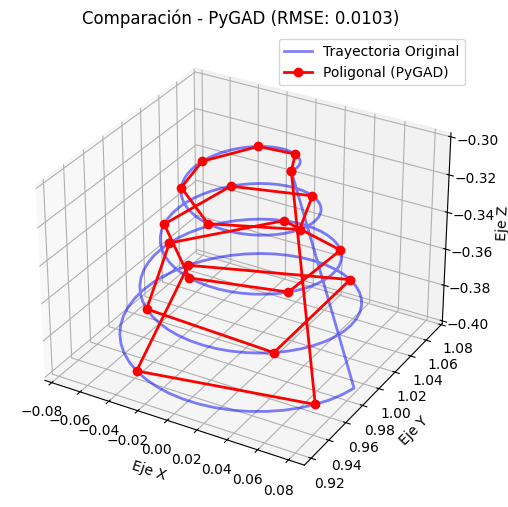

DEAP
RMSE Obtenido: 0.010445



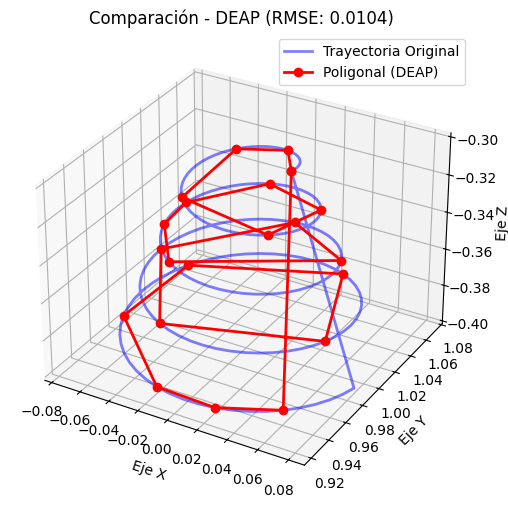

In [23]:

soluciones = {
    "MEALPY": mejor_individuo,
    "PyGAD": solution.astype(int),
    "DEAP": np.array(hof[0])
}

# Bucle para procesar, calcular el RMSE yvisualizar en secuencia
for nombre_lib, ind in soluciones.items():
    vertices_optimos = individuo_a_vertices(ind)
    rmse_actual = calcular_rmse(vertices_optimos, trayectoria)

    print(f"{nombre_lib}")
    print(f"RMSE Obtenido: {rmse_actual:.6f}\n")

    # Gráfica secuencial para cada librería
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot(trayectoria[:, 0], trayectoria[:, 1], trayectoria[:, 2],
            label='Trayectoria Original', color='blue', alpha=0.5, linewidth=2)
    ax.plot(vertices_optimos[:, 0], vertices_optimos[:, 1], vertices_optimos[:, 2],
            label=f'Poligonal ({nombre_lib})', color='red', marker='o', linestyle='-', linewidth=2)

    ax.set_title(f'Comparación - {nombre_lib} (RMSE: {rmse_actual:.4f})')
    ax.set_xlabel('Eje X')
    ax.set_ylabel('Eje Y')
    ax.set_zlabel('Eje Z')
    ax.legend()

    plt.show()